# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('drive/MyDrive/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [3]:
avg_count_by_month = df.groupby(df.month)['count'].mean()

In [4]:
avg_count_by_month

,count
month,
1,90.366516
2,110.003330
3,148.169811
4,184.160616
5,219.459430
6,242.031798
7,235.325658
8,234.118421
9,233.805281


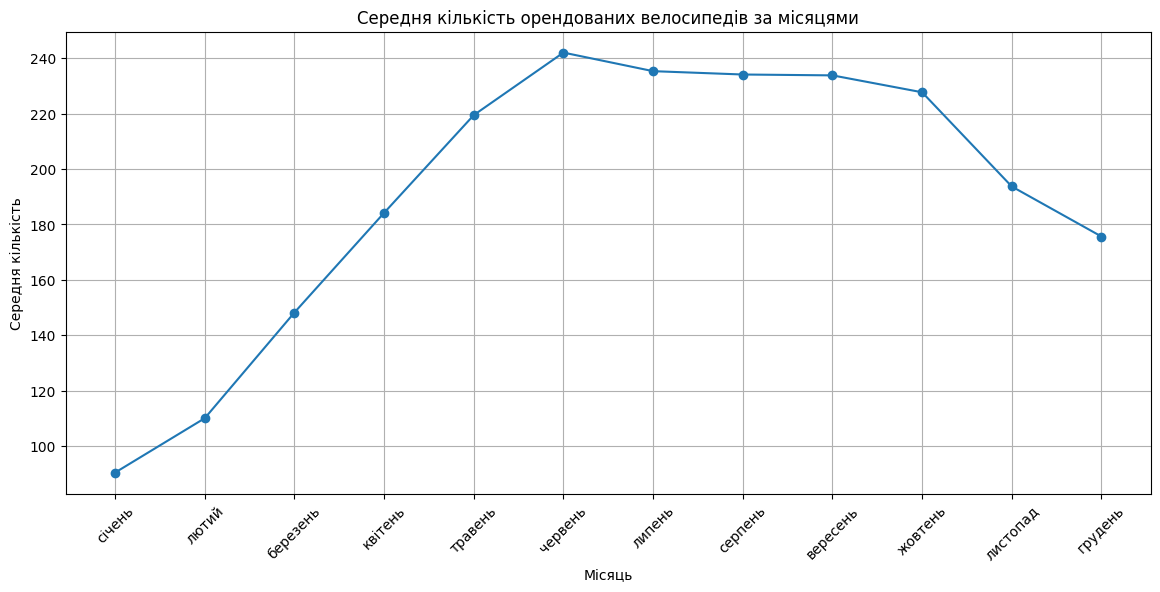

In [5]:
#Використовуючи Pandas (DataFrame.plot())

ax = avg_count_by_month.plot(
    figsize=(14, 6),
    kind='line',
    marker='o',
    title='Середня кількість орендованих велосипедів за місяцями',
    xlabel='Місяць',
    ylabel='Середня кількість',
    grid=True
    )
months = [
    'січень', 'лютий', 'березень', 'квітень',
    'травень', 'червень', 'липень', 'серпень',
    'вересень', 'жовтень', 'листопад', 'грудень'
]

# ЯВНО задаємо всі 12 позицій
ax.set_xticks(range(1, 13))

# ЯВНО задаємо всі підписи
ax.set_xticklabels(months)

plt.xticks(rotation=45)

plt.show()


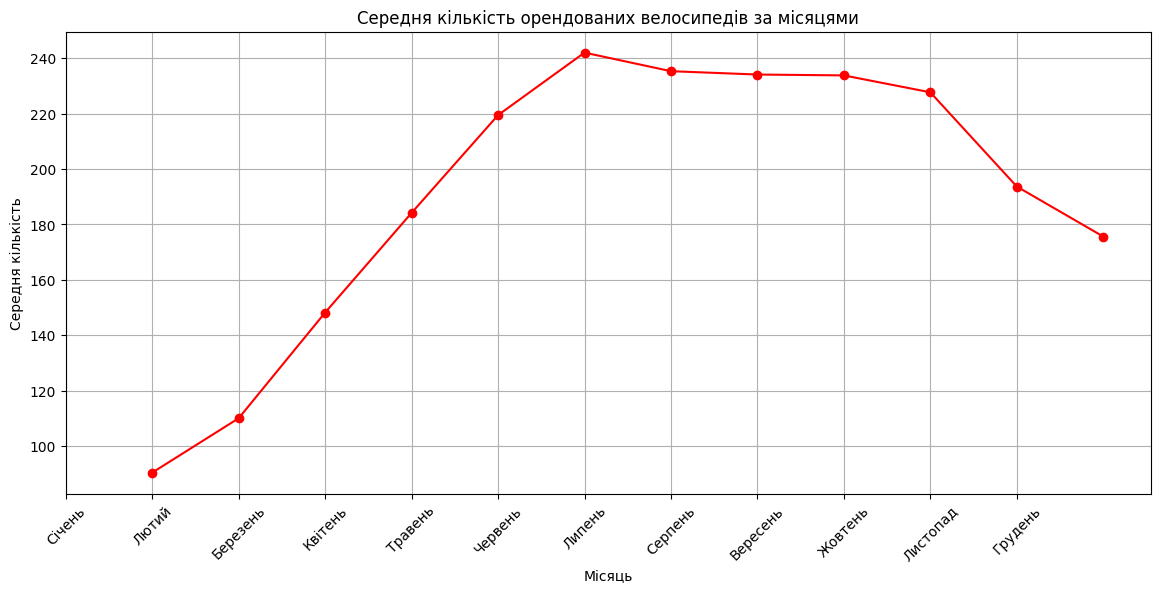

In [6]:
#2.Використовуючи Matplotlib
months = [
    'Січень', 'Лютий', 'Березень', 'Квітень',
    'Травень', 'Червень', 'Липень', 'Серпень',
    'Вересень', 'Жовтень', 'Листопад', 'Грудень'
]

plt.figure(figsize=(14, 6))

plt.plot(avg_count_by_month, 'o-', color='red')

# заміна чисел на назви місяців
plt.xticks(range(12), months, rotation=45)

plt.title('Середня кількість орендованих велосипедів за місяцями')
plt.xlabel('Місяць')
plt.ylabel('Середня кількість')

plt.grid(True)

plt.show()

**Відповідь:** на мій погляд графіки не сильно відрізняються візуально. В мене вийшло скоріше з Matplotlib, хоча з Pandas зручніше. Мені подобаються 2 підходи. Matplotlib кращий для тонких налаштувань.В Pandas використали метод .plot(), в якому параметри передаються одразу в метод — більш швидкий спосіб побудови.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [7]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень2

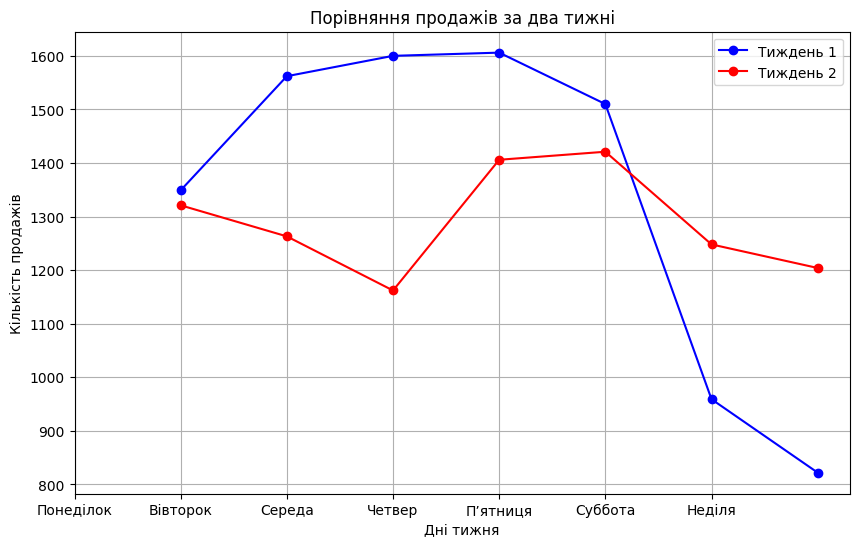

In [8]:
plt.figure(figsize=(10, 6))
# Графіки
plt.plot(
    days,
    sales_week1,
    marker='o',
    color='blue',
    label='Тиждень 1'
)
plt.plot(
    days,
    sales_week2,
    marker='o',
    color='red',
    label='Тиждень 2'
    )
# заміна чисел на назви днів
days_n = [
    'Понеділок', 'Вівторок', 'Середа', 'Четвер',
    'Пʼятниця', 'Суббота', 'Неділя'
]
plt.xticks(range(7), days_n, rotation=0)

plt.title('Порівняння продажів за два тижні')
plt.xlabel('Дні тижня')
plt.ylabel('Кількість продажів')
plt.grid(True)
plt.legend()
plt.show()


**Відповідь:** 1) В другий тиждень продажі були стабільніше (лінія змінюється плавніше,менше різких стрибків між днями,менший розкид значень). 2) Для цього використаємо міри варіативності:
1. Стандартне відхилення
Чим менше стандартне відхилення - тим стабільніші продажі.
import numpy as np
std_week1 = np.std(sales_week1)
std_week2 = np.std(sales_week2)
print(std_week1)
print(std_week2)
2. Дисперсія - показує розкид значень:
var_week1 = np.var(sales_week1)
var_week2 = np.var(sales_week2)
3. Діапазон значень - цe різниця між максимумом і мінімумом:
range_week1 = max(sales_week1) - min(sales_week1)
range_week2 = max(sales_week2) - min(sales_week2)
Стандартне відхилення крайкраще характеризує стабільність даних.
Ми бачимо, що після розрахунків нижче більш стабільніший 2 тиждень, у якого:менший розкид значень, менше стандартне відхилення, плавніші зміни на графіку.

In [9]:
#1. Стандартне відхилення
#Чим менше стандартне відхилення - тим стабільніші продажі.
import numpy as np
std_week1 = np.std(sales_week1)
std_week2 = np.std(sales_week2)
print(std_week1)
print(std_week2)

299.99857142517004
90.9060964256355


In [10]:
#2.Дисперсія - показує розкид значень
var_week1 = np.var(sales_week1)
var_week2 = np.var(sales_week2)
print(var_week1)
print(var_week2)

89999.14285714286
8263.91836734694


In [11]:
#3.Діапазон значень - цe різниця між максимумом і мінімумом
range_week1 = max(sales_week1) - min(sales_week1)
range_week2 = max(sales_week2) - min(sales_week2)
print(range_week1)
print(range_week2)

784
259


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [12]:
avg_temp_by_month = df.groupby(df.month)['temp'].mean()

In [13]:
avg_hour_count_by_season = df.groupby(df.season)['count'].mean()

In [14]:
avg_hour_count_by_season

,count
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


In [15]:
avg_temp_by_month

,temp
month,
1,9.840000
2,11.798535
3,15.902175
4,18.718372
5,22.674079
6,27.064496
7,30.841711
8,29.736689
9,25.779032


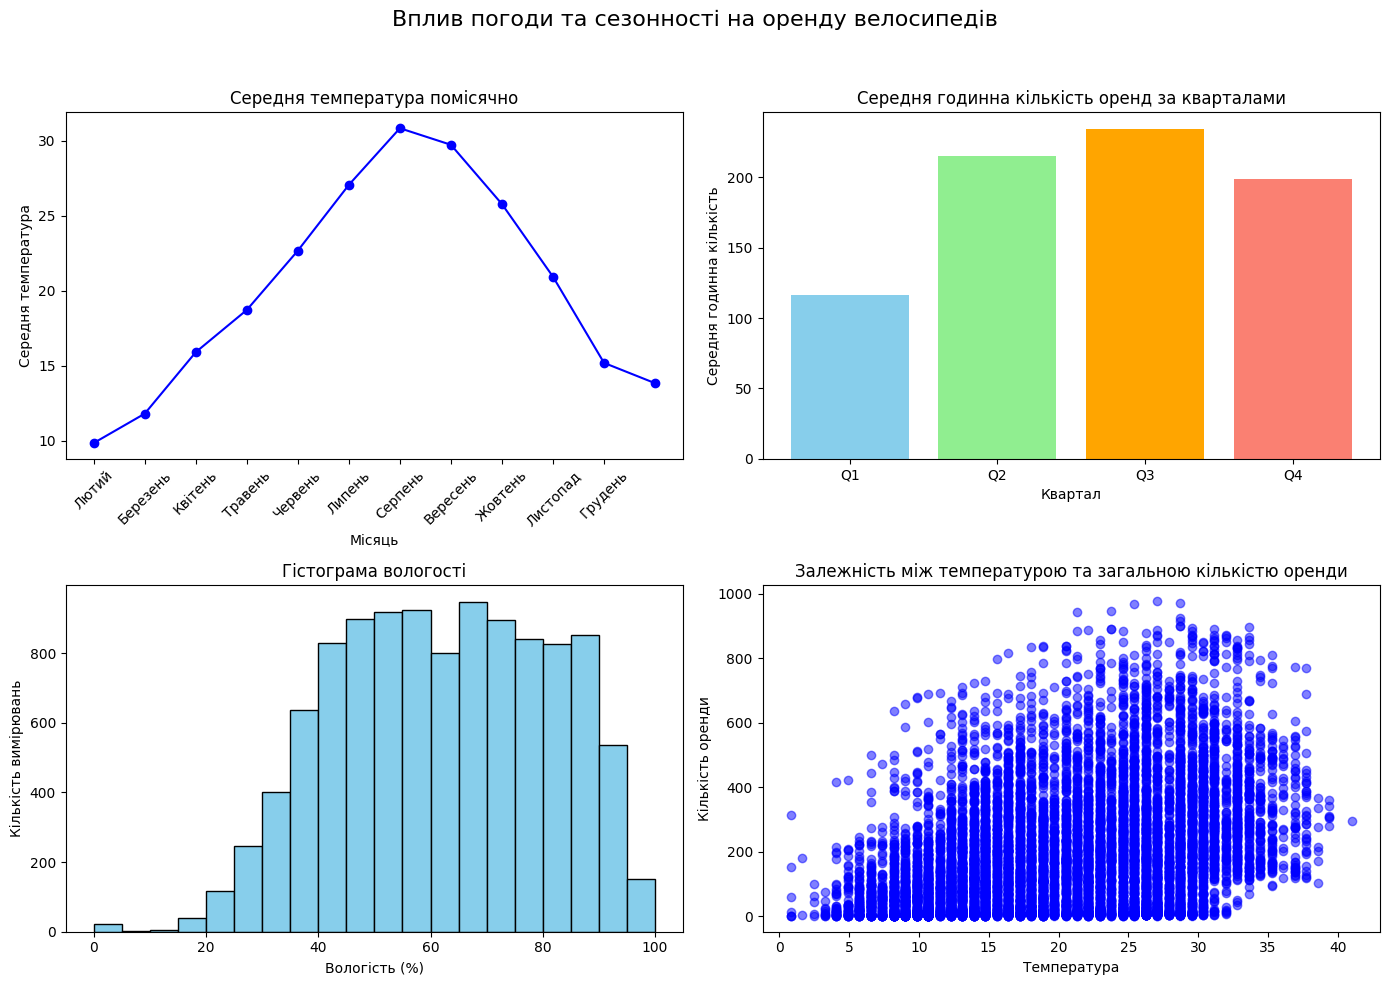

In [16]:
# Дані
x = np.linspace(0, 10, 100)

plt.figure(figsize=(14, 10))

# Графік 1 - Лінійний графік середньої температури помісячно.
plt.subplot(2, 2, 1)
months = [
    'Січень', 'Лютий', 'Березень', 'Квітень',
    'Травень', 'Червень', 'Липень', 'Серпень',
   'Вересень', 'Жовтень', 'Листопад', 'Грудень'
]
# заміна чисел на назви місяців
plt.xticks(range(12), months, rotation=45)
plt.plot(avg_temp_by_month,
         'o-',
         color='blue'
)
plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Середня температура')

# Графік 2 - Стовпчикова діаграма середньої годинної кількості оренд за кварталам
plt.subplot(2, 2, 2)
seasons = ['Q1', 'Q2', 'Q3', 'Q4']
plt.bar(
    seasons,
    avg_hour_count_by_season,
    color=['skyblue', 'lightgreen', 'orange', 'salmon']
)
plt.title('Cередня годинна кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Cередня годинна кількість')


# Графік 3 - Гістограма вологості за всіма погодинними вимірами
plt.subplot(2, 2, 3)
plt.hist(df['humidity'],
    bins=20,
    color='skyblue',
    edgecolor='black'
)
plt.title('Гістограма вологості')
plt.xlabel('Вологість (%)')
plt.ylabel('Кількість вимірювань')

# Графік 4 - Scatter plot температури vs кількості оренд
plt.subplot(2, 2, 4)
plt.scatter(
    df['temp'],
    df['count'],
    alpha=0.5,
    color='blue'
)
plt.title('Залежність між температурою та загальною кількістю оренди')
plt.xlabel('Температура')
plt.ylabel('Кількість оренди')

# Заголовок всієї фігури — треба обійтись без `fig.suptitle()`
plt.suptitle('Вплив погоди та сезонності на оренду велосипедів', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

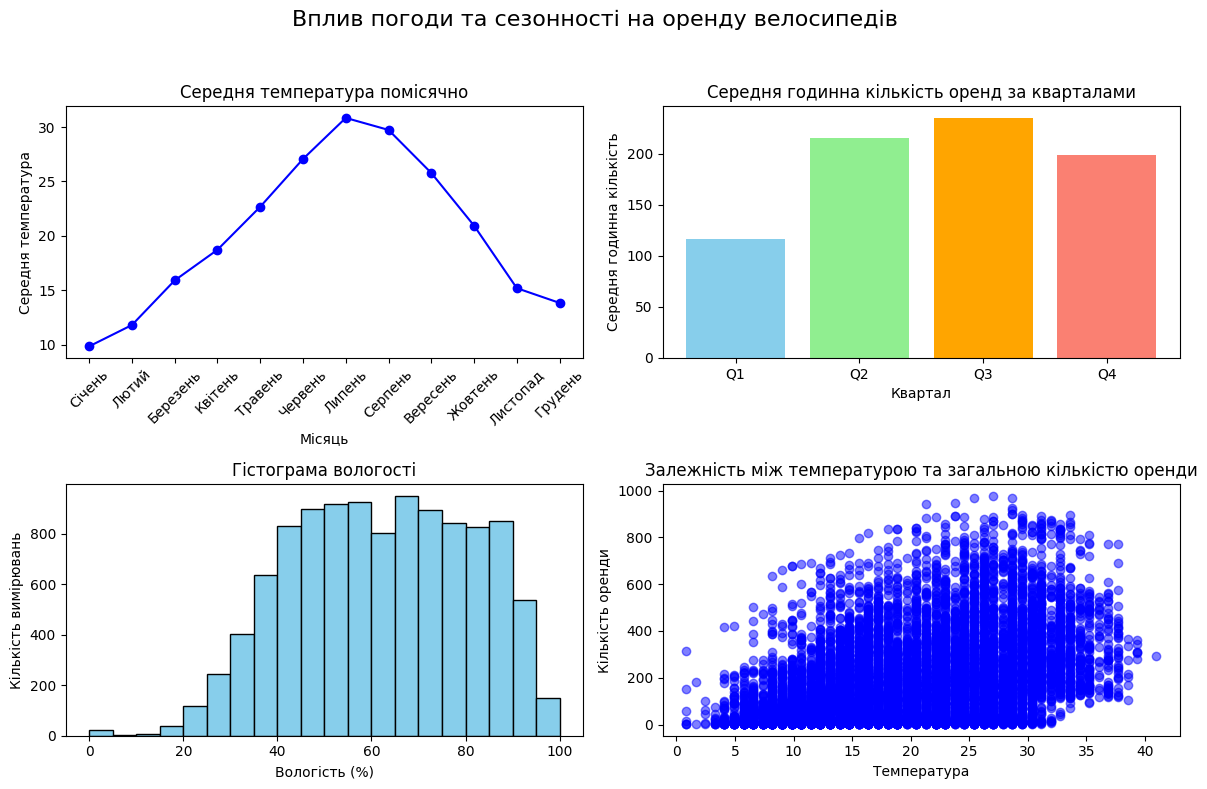

In [17]:
# Дані
x = np.linspace(0, 10, 100)

# Створюємо 2x2 сітку графіків
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Графік 1 - Лінійний графік середньої температури помісячно.
months = [
    'Січень', 'Лютий', 'Березень', 'Квітень',
    'Травень', 'Червень', 'Липень', 'Серпень',
   'Вересень', 'Жовтень', 'Листопад', 'Грудень'
]
# заміна чисел на назви місяців
ax[0, 0].plot(avg_temp_by_month,
              'o-',
              color='blue')

ax[0, 0].set_xticks(range(1, 13))
ax[0, 0].set_xticklabels(months, rotation=45)

ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Середня температура')

# Графік 2 - Стовпчикова діаграма середньої годинної кількості оренд за кварталами

seasons = ['Q1', 'Q2', 'Q3', 'Q4']
ax[0, 1].bar(seasons,
             avg_hour_count_by_season,
             color=['skyblue', 'lightgreen', 'orange', 'salmon']
             )
ax[0, 1].set_title('Cередня годинна кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Cередня годинна кількість')

# Графік 3 - Гістограма вологості за всіма погодинними вимірами
ax[1, 0].hist(df['humidity'],
              bins=20,
              color='skyblue',
              edgecolor='black'
              )
ax[1, 0].set_title('Гістограма вологості')
ax[1, 0].set_xlabel('Вологість (%)')
ax[1, 0].set_ylabel('Кількість вимірювань')

# Графік 4 - Scatter plot температури vs кількості оренд
ax[1, 1].scatter(df['temp'],
                 df['count'],
                 alpha=0.5,
                 color='blue')
ax[1, 1].set_title('Залежність між температурою та загальною кількістю оренди')
ax[1, 1].set_xlabel('Температура')
ax[1, 1].set_ylabel('Кількість оренди')

# Загальний вигляд
fig.suptitle('Вплив погоди та сезонності на оренду велосипедів', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # залишаємо місце для заголовка
plt.show()

**Відповідь:** plt.subplot() - створює subplot по одному, не дуже зручний, працює через «поточну» вісь, старіший стиль, важче масштабувати. Підходить більше для простих графіків.
plt.subplots() - відразу створює всю сітку, зручний для складних фігур,
має явні Axes, сучасний стиль, легко працювати з багатьма графіками. Підходить для аналітики, dashboardів,складних візуалізацій.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [21]:
import matplotlib.dates as mdates

In [42]:
monthly_stats = df['count'].resample('ME').agg(['mean', 'max', 'min'])
monthly_stats

,mean,max,min
datetime,,,
2011-01-31,54.645012,219,1
2011-02-28,73.641256,327,1
2011-03-31,86.849776,332,1
2011-04-30,111.026374,452,1
2011-05-31,174.809211,611,1
2011-06-30,196.877193,638,1
2011-07-31,203.614035,596,1
2011-08-31,182.666667,600,1
2011-09-30,174.622517,628,1


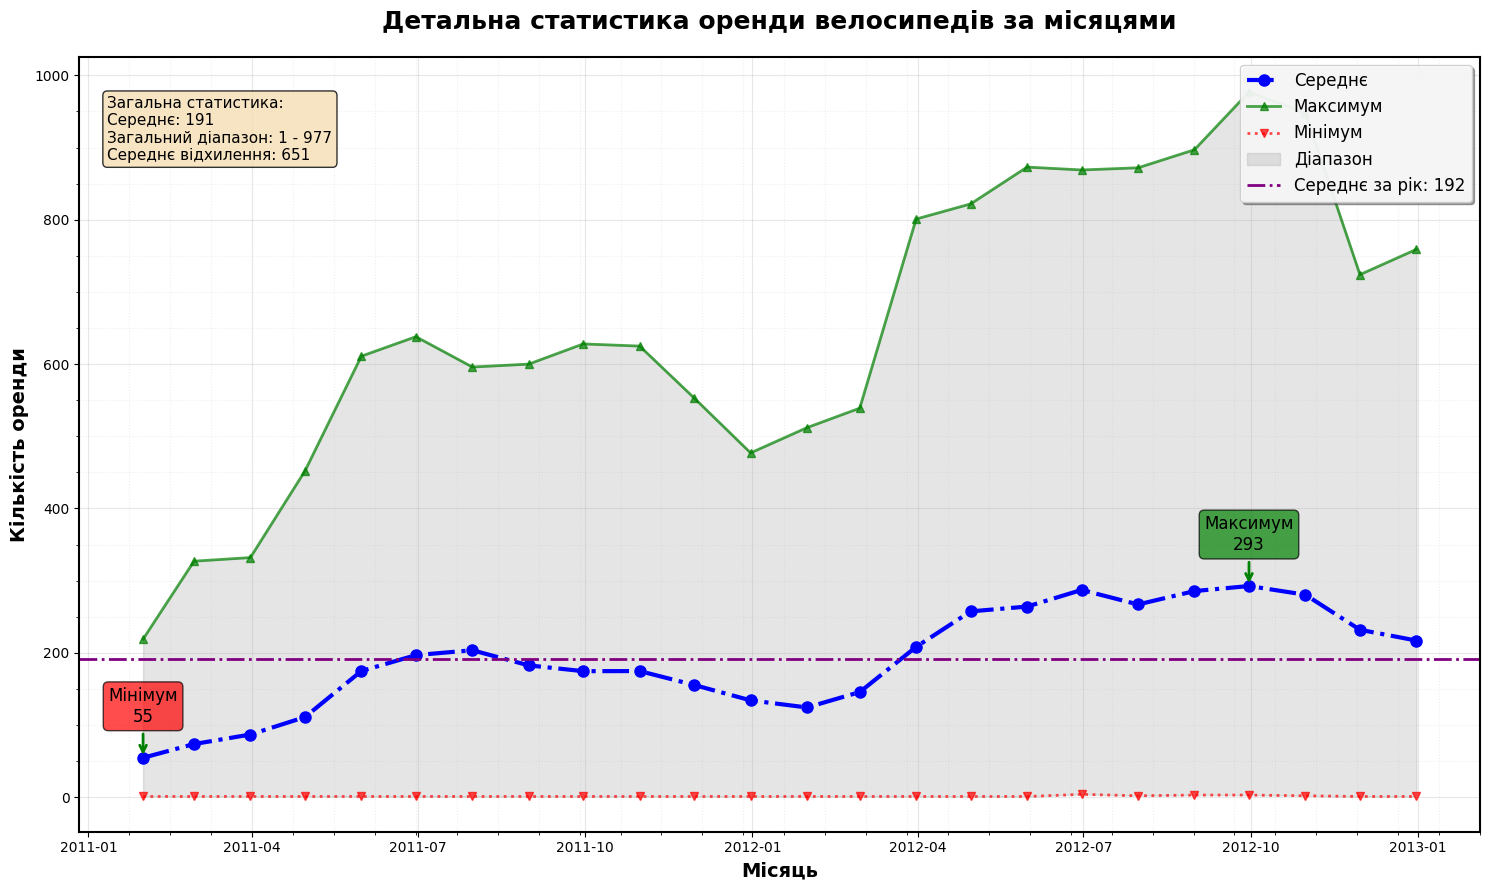

In [40]:
fig, ax = plt.subplots(figsize=(15, 9))

# Малюємо лінії з різними стилями
ax.plot(monthly_stats.index, monthly_stats['mean'], 'b-.o', linewidth=3,
        label='Середнє', markersize=8)
ax.plot(monthly_stats.index, monthly_stats['max'], 'g-^', linewidth=2,
        label='Максимум', markersize=6, alpha=0.7)
ax.plot(monthly_stats.index, monthly_stats['min'], 'r:v', linewidth=2,
        label='Мінімум', markersize=6, alpha=0.7)

# Заливка між max та min (правильний синтаксис)
ax.fill_between(monthly_stats.index, monthly_stats['min'], monthly_stats['max'],
                alpha=0.2, color='gray', label='Діапазон')

# Додаємо анотації для найвищого середнього значення
mean_idx = monthly_stats['mean'].idxmax()
mean_val = monthly_stats['mean'].max()
ax.annotate(f'Максимум\n{mean_val:.0f}',
            xy=(mean_idx, mean_val), xytext=(mean_idx, mean_val + 50),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='green', alpha=0.7))

# Додаємо анотації для найнижчого середнього значення
mean_idx = monthly_stats['mean'].idxmin()
mean_val = monthly_stats['mean'].min()
ax.annotate(f'Мінімум\n{mean_val:.0f}',
            xy=(mean_idx, mean_val), xytext=(mean_idx, mean_val + 50),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='red', alpha=0.7))

# Налаштування осей
ax.set_xlabel('Місяць', fontsize=14, fontweight='bold')
ax.set_ylabel('Кількість оренди', fontsize=14, fontweight='bold')
ax.set_title('Детальна статистика оренди велосипедів за місяцями',
             fontsize=18, fontweight='bold', pad=20)

# Додаємо сітку з різними стилями
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

# Додаємо середню лінію за весь період
overall_mean = df['count'].mean()
ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')

# Покращуємо легенду
ax.legend(loc='upper right', fontsize=12, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)

# Додаємо текст з додатковою статистикою
textstr = f'Загальна статистика: \n'
textstr += f'Середнє: {(monthly_stats["mean"]).mean():.0f}\n'
textstr += f'Загальний діапазон: {monthly_stats["min"].min():.0f} - {monthly_stats["max"].max():.0f}\n'
textstr += f'Середнє відхилення: {(monthly_stats["max"] - monthly_stats["min"]).mean():.0f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Налаштування рамки
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

**Відповідь:** 1. Яка перевага додавання анотацій на графік? - Вони допомагають виділити важливі точки, піки, спади на графіку. Графік стає більш зрозумілим і легким для аналізу, так як користувач одразу бачить ключові значення та пояснення.
2. Для чого використовується fill_between()? - Використовується для зафарбовування області між двома лініями або між лінією та віссю. Допомагає: показати діапазон значень,
виділити різницю між даними,
візуалізувати області зростання/спаду,
зробити графік більш читабельним.
3. Як текстовий блок допомагає в інтерпретації даних? - Додає пояснення саме на графік:описує важливі результати, пояснює тенденції,
показує статистику або висновки,
допомагає швидше зрозуміти зміст графіка (наприклад: середнє значення,
максимум/мінімум,відсоток, діапазон, висновок аналізу).
